# GOES-18 ABI Day/Night True Color — executed example

Plain True Color needs sunlight, so it is black at night. The **day/night**
composite keeps real color where the sun is up and shows clouds where it is
down, blended smoothly through twilight from the per-pixel solar zenith angle.

At night the clouds come from the **night microphysics** colour infrared RGB
(R = 12.3−10.3 µm, G = 10.3−3.9 µm, B = 10.3 µm), the same idea CIRA/RAMMB
day/night products use: fog and low water cloud separate from thick high ice
cloud **by colour**, not as a flat grey.
See [docs/RGB.md](../docs/RGB.md#daynight-true-color).

This notebook renders the same command at two times on 3 October 2023 over the
Shishaldin region:

1. **17:00 UTC** — local pre-dawn, the scene is dark and the colour night RGB shows the cloud field;
2. **19:00 UTC** — after sunrise, real True Color with the volcanic ash plume.


## Setup

In [1]:
import logging
import sys
import warnings
from pathlib import Path

from IPython.display import Image, display
from satpy import Scene
from satpy.utils import PerformanceWarning

logging.getLogger("pyspectral.rsr_reader").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.goes18_coverage_data import SCAN_LABELS, download_coverage
from examples.domains import DOMAINS
from examples.render_satellite import crop_and_resample_scene, save_map
from examples.day_night import compose_day_night_image


## Parameters

In [2]:
# True Color channels (C01/C02/C03) plus the infrared bands the colour night
# RGB needs (C07 3.9 um, C13 10.3 um, C15 12.3 um).
CHANNELS = ("C01", "C02", "C03", "C07", "C13", "C15")

# Named domain from examples/domains.py (the enlarged Shishaldin box).
DOMAIN_NAME = "shishaldin_big"
DOMAIN = DOMAINS[DOMAIN_NAME]
DOMAIN_RESOLUTION = 0.02

DATA_DIR = REPO_ROOT / "data" / "goes18-20231003-1900"
OUTPUT_DIR = REPO_ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Render helper

One function loads True Color plus C13 for a coverage, crops to the domain on a
regular lon/lat grid, blends day and night, and saves the
image with a longitude/latitude grid and coastlines.


In [3]:
def render_day_night(coverage, output_name):
    files = download_coverage(DATA_DIR, coverage, CHANNELS)
    scene = Scene(reader="abi_l1b", filenames=files)
    scene.load(["true_color", "night_microphysics"], generate=True)
    cropped = crop_and_resample_scene(
        scene, domain=DOMAIN, resolution=DOMAIN_RESOLUTION
    )
    image, night_source = compose_day_night_image(cropped, "goes")
    output = OUTPUT_DIR / output_name
    save_map(
        cropped,
        "true_color",
        output,
        title="GOES-18 ABI True Color (Day/Night)",
        image=image,
    )
    print(f"night source: {night_source}")
    return output


## 1. Night — 17:00 UTC

Shishaldin is in darkness. True Color alone would be black; the day/night blend
switches to the colour night microphysics RGB, so cloud structure and type stay
visible.


The following datasets were not created and may require resampling to be generated: DataID(name='true_color')


night source: night_microphysics


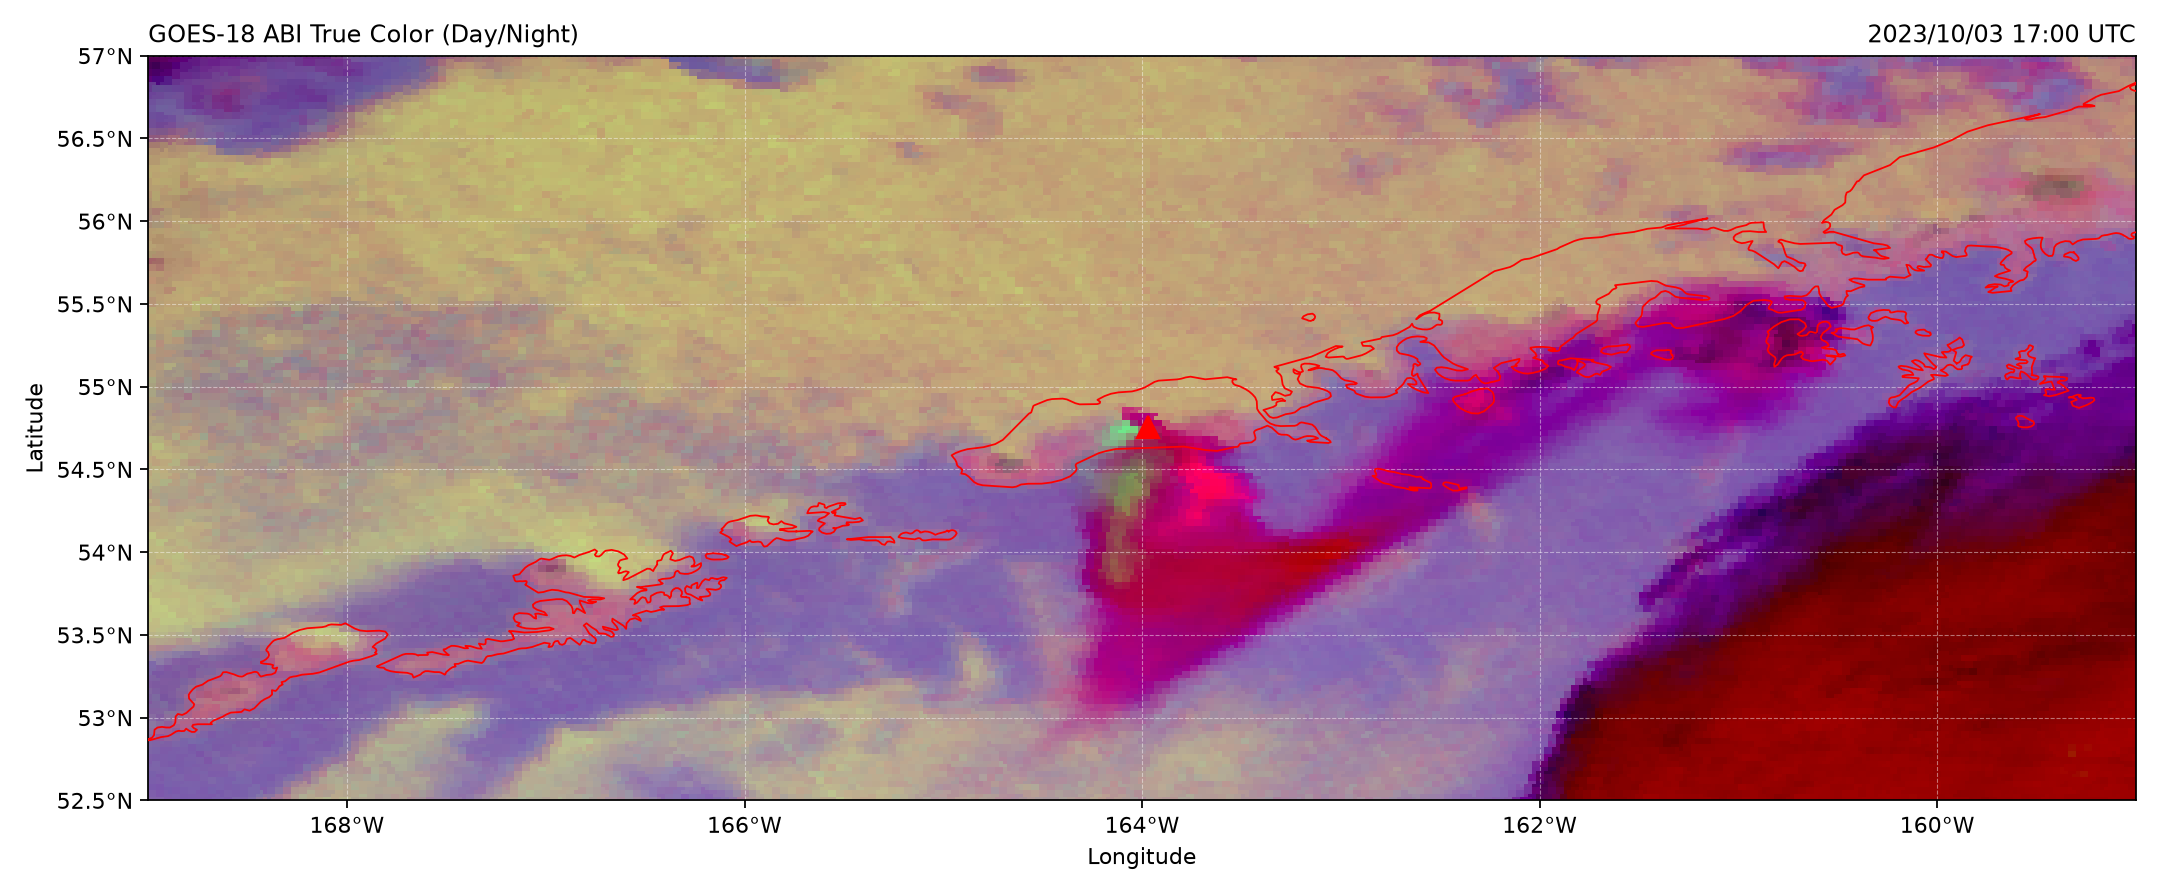

In [4]:
night_output = render_day_night("full_disk_night", "goes18_day_night_1700.png")
display(Image(filename=str(night_output)))


## 2. Day — 19:00 UTC

After sunrise the same command produces real True Color. The brown streak south
of the volcano is the Shishaldin ash plume.


The following datasets were not created and may require resampling to be generated: DataID(name='true_color')


night source: night_microphysics


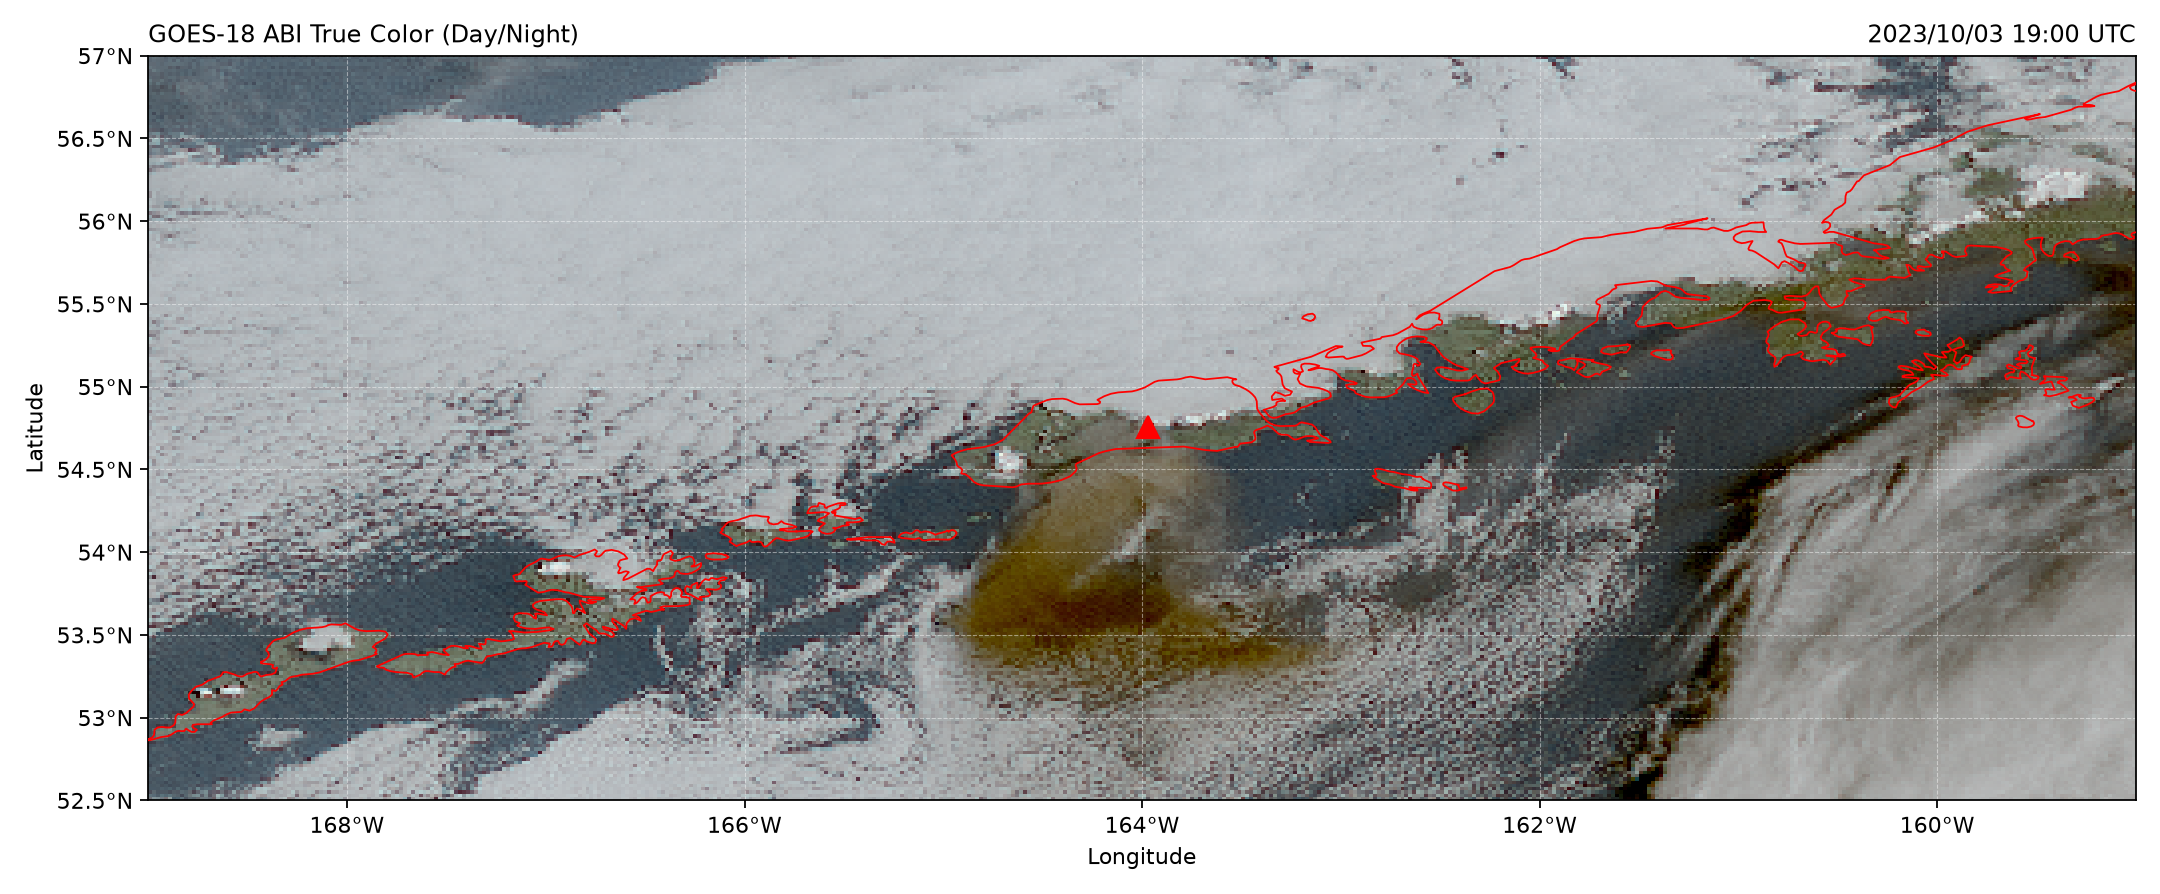

In [5]:
day_output = render_day_night("full_disk", "goes18_day_night_1900.png")
display(Image(filename=str(day_output)))


## How it works

* `compose_day_night_image` reads the enhanced True Color RGB and the enhanced
  night microphysics RGB, computes the solar zenith angle per pixel, and blends
  them so day keeps real colour and night keeps colour cloud structure.
* If `night_microphysics` cannot be built (C07/C13/C15 missing) it falls back to
  the Day/Night Band on VIIRS, then to a single grey infrared window band.
* The twilight band (solar zenith 85°–88°) is a constant at the top of
  `examples/day_night.py`.

## Next steps

* Change `DOMAIN` to your own study area, or use a named domain from
  `examples/domains.py`.
* From the command line:

  ```bash
  python examples/render_satellite.py --sensor goes --files "data/goes/*.nc" \
      --composite day_night --domain shishaldin
  ```
